# SignalScout - data exploration

What the two public datasets contain, how they were cleaned, and the evidence behind three design decisions:

1. **Device profiles** - many readings miss RSRQ/SINR/RSSI, so the classifier is trained with realistic missing metrics.
2. **Which data feeds the Gaussian Process** - only data with real spatial structure (Cork drive tests).
3. **Why speed is only a partial proxy for radio conditions** - it matters for the phone-browser probe.

Cleaning itself is done by `ml/prepare_data.py`; this notebook reads its outputs.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT / "backend"), str(ROOT / "ml")]
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import _plots as P
get_ipython().run_line_magic("matplotlib", "inline")
P.style()
pd.set_option("display.width", 140, "display.max_columns", 30)
print("project root:", ROOT)

project root: D:\abstracts\Madhav\CSDS\B\CSDS-B-B2\8.ProjectCode


## 1. Cleaning report

In [2]:
report = json.loads((ROOT / "data/processed/prep_report.json").read_text())
for name, info in report.items():
    print(f"== {name}")
    for k, v in info["steps"].items():
        print(f"   {k:34s} {v}")
    print("   label share:", info["label_share"])

== lte_speed
   raw_rows                           174523
   trace_files                        135
   after_valid_time_and_position      174523
   after_keep_operators_A_B           174243
   level_sentinels_removed            69
   after_drop_unlabellable            174233
   after_drop_exact_duplicates        173366
   label share: {'Strong': 0.539, 'Weak': 0.3292, 'Dead': 0.1317}
== cellular_analysis
   raw_rows                           16829
   after_valid                        16829
   label share: {'Strong': 0.9569, 'Weak': 0.043, 'Dead': 0.0001}


## 2. Cork drive-test traces (4G LTE Speed Dataset)

In [3]:
lte = pd.read_csv(ROOT / "data/processed/lte_speed_clean.csv.gz", parse_dates=["ts"])
print(lte.shape)
display(lte.groupby("mobility").agg(traces=("device_key", "nunique"), readings=("label", "size")))
display(pd.crosstab(lte.network_mode, lte.label.map({0: "Strong", 1: "Weak", 2: "Dead"}), margins=True))

(173366, 19)


,traces,readings
mobility,,
bus,16,10599
car,53,75795
pedestrian,31,33484
static,15,15248
train,20,38240


label,Dead,Strong,Weak,All
network_mode,,,,
EDGE,3,1134,36,1173
HSDPA,0,5,0,5
HSPA+,6,39495,2907,42408
HSUPA,4,7185,714,7903
LTE,22826,44119,53355,120300
UMTS,1,1514,62,1577
All,22840,93452,57074,173366


### Signal level by class
The documented ranges draw the class borders; SINR and RSRQ explain the overlap (a reading with good RSRP can still be Weak).

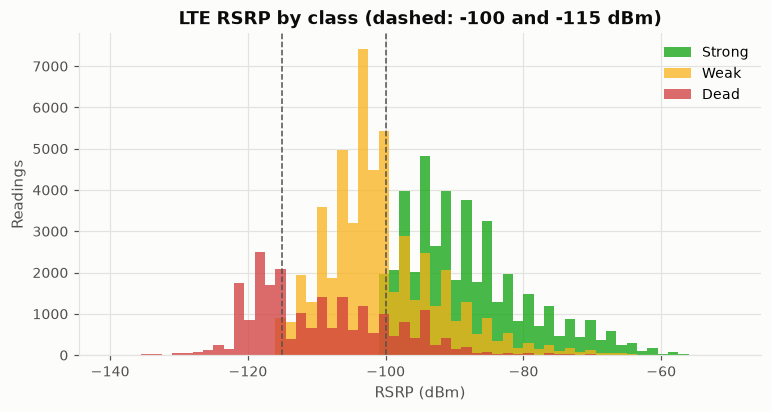

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.8))
d = lte[lte.family == "lte_nr"]
for k, name in enumerate(["Strong", "Weak", "Dead"]):
    ax.hist(d["level"][d.label == k], bins=60, range=(-140, -50), alpha=0.75, color=P.STATUS[name], label=name)
ax.axvline(-100, color=P.TEXT_2, ls="--", lw=1); ax.axvline(-115, color=P.TEXT_2, ls="--", lw=1)
ax.set_xlabel("RSRP (dBm)"); ax.set_ylabel("Readings"); ax.set_title("LTE RSRP by class (dashed: -100 and -115 dBm)"); ax.legend()
plt.show()

### Missing metrics - why the classifier is trained on device profiles

In [5]:
miss = lte.groupby("family")[["level", "quality", "sinr", "rssi", "cqi"]].apply(lambda g: g.isna().mean().round(3))
display(miss)

,level,quality,sinr,rssi,cqi
family,,,,,
2g,0.0,0.981,1.0,0.000,1.0
3g,0.0,0.001,1.0,1.000,1.0
lte_nr,0.0,0.000,0.0,0.093,0.0


## 3. Spatial structure - which data can feed the Gaussian Process

In [6]:
from sklearn.neighbors import NearestNeighbors

def neighbour_corr(lat, lon, v):
    X = np.radians(np.column_stack([lat, lon]))
    _, idx = NearestNeighbors(n_neighbors=2, metric="haversine").fit(X).kneighbors(X)
    return float(np.corrcoef(v, v[idx[:, 1]])[0, 1])

a = lte[lte.family == "lte_nr"].groupby(["lat", "lon"])["level"].mean().reset_index()
s = lte[lte.state == "D"].groupby(["lat", "lon"]).dl_kbps.median().reset_index()
patna = pd.read_csv(ROOT / "data/processed/cellular_analysis_clean.csv.gz", parse_dates=["ts"])
print("Cork   RSRP          neighbour correlation", round(neighbour_corr(a.lat, a.lon, a["level"].to_numpy()), 3))
print("Cork   log speed     neighbour correlation", round(neighbour_corr(s.lat, s.lon, np.log1p(s.dl_kbps.to_numpy())), 3))
print("Patna  signal level  neighbour correlation", round(neighbour_corr(patna.lat, patna.lon, patna["level"].to_numpy()), 3))

Cork   RSRP          neighbour correlation 0.87
Cork   log speed     neighbour correlation 0.648


Patna  signal level  neighbour correlation 0.007


Cork readings vary smoothly in space; the Patna signal values do not (correlation about 0), so Patna is not used for the Gaussian Process.

In [7]:
print("Patna: correlation of signal level with latency / throughput, per network type")
display(patna.groupby("network_type").apply(lambda g: pd.Series({
    "readings": len(g),
    "corr_latency": round(g["level"].corr(g.latency_ms), 3),
    "corr_throughput": round(g["level"].corr(g.throughput_mbps), 3)}), include_groups=False))

Patna: correlation of signal level with latency / throughput, per network type


,readings,corr_latency,corr_throughput
network_type,,,
3G,4208.0,-0.005,0.015
4G,4219.0,-0.023,0.027
5G,4178.0,-0.007,-0.025
LTE,4224.0,0.010,0.004


## 4. Speed versus radio class - the phone-probe question
A phone browser can measure speed but not radio metrics. Speed overlaps heavily between classes because it also depends on cell load.

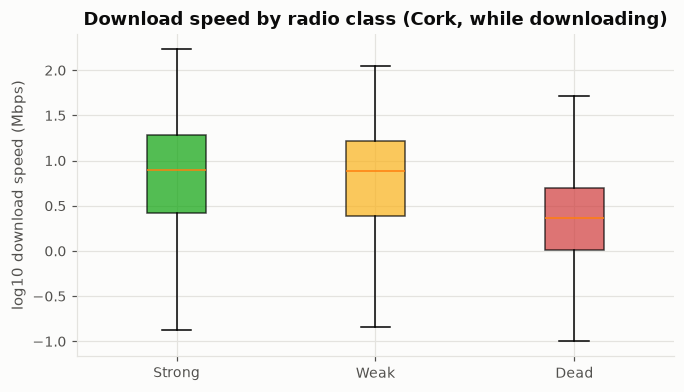

label
Strong    7.784
Weak      7.694
Dead      2.315
Name: dl_kbps, dtype: float64


In [8]:
d = lte[(lte.state == "D") & lte.dl_kbps.notna()]
fig, ax = plt.subplots(figsize=(7, 3.8))
data = [np.log10(np.maximum(d.dl_kbps[d.label == k] / 1000, 0.05)) for k in range(3)]
bp = ax.boxplot(data, tick_labels=["Strong", "Weak", "Dead"], patch_artist=True, showfliers=False)
for patch, name in zip(bp["boxes"], ["Strong", "Weak", "Dead"]):
    patch.set_facecolor(P.STATUS[name]); patch.set_alpha(0.7)
ax.set_ylabel("log10 download speed (Mbps)"); ax.set_title("Download speed by radio class (Cork, while downloading)")
plt.show()
print(d.groupby("label").dl_kbps.median().rename(index={0: "Strong", 1: "Weak", 2: "Dead"}) / 1000)